In [145]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import orthogonal_procrustes
from gensim.models import KeyedVectors

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)

set_seed(42)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [146]:
# ── Helper functions ──────────────────────────────────────────────────────────

def rankMe(Z, eps=1e-6):
    """Smooth rank measure for an N×K embedding matrix."""
    z_stds = Z.std(dim=0)
    p_k = z_stds / (torch.norm(z_stds, p=1) + eps)
    r_k = p_k * torch.log(p_k)
    return torch.exp(-r_k.sum())


def compute_mrr(recon1, recon2):
    """
    Mean Reciprocal Rank: for each point i in recon1, rank all points in recon2
    by distance and record the rank of point i (the true match).
    MRR = mean(1 / rank). Perfect alignment → MRR = 1.0.
    """
    n = len(recon1)

    # Pairwise squared distances: (n, n)
    # ||a - b||^2 = ||a||^2 + ||b||^2 - 2 a·b
    r1_sq = np.sum(recon1 ** 2, axis=1, keepdims=True)   # (n, 1)
    r2_sq = np.sum(recon2 ** 2, axis=1, keepdims=True)   # (n, 1)
    dists = r1_sq + r2_sq.T - 2 * (recon1 @ recon2.T)    # (n, n)

    # For each row i, rank of column i (the true match) — argsort gives ascending order
    ranks = (np.argsort(dists, axis=1) == np.arange(n)[:, None]).argmax(axis=1) + 1  # 1-indexed

    mrr = float(np.mean(1.0 / ranks))

    print(f"=== Mean Reciprocal Rank ===")
    print(f"MRR:              {mrr:.4f}  (perfect = 1.0000, random ≈ {1/n:.6f})")
    print(f"Median rank:      {int(np.median(ranks))} / {n}")
    print(f"Rank 1 hits:      {np.sum(ranks == 1)} / {n}  ({np.mean(ranks == 1)*100:.2f}%)")
    print(f"Rank ≤ 10 hits:   {np.sum(ranks <= 10)} / {n}  ({np.mean(ranks <= 10)*100:.2f}%)")

    return mrr, ranks


# def compute_relative_representations(embeddings, anchors):
#     # Normalize both (in case they aren't already)
#     emb_norm = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-8)
#     anc_norm = anchors   / (np.linalg.norm(anchors,    axis=1, keepdims=True) + 1e-8)
#     return emb_norm @ anc_norm.T  # (n_samples, n_anchors)

def compute_relative_representations(embeddings, anchors):
    """
    Compute relative representations using cosine similarity.
    
    Args:
        embeddings: numpy array of shape (n_samples, embedding_dim)
        anchors: numpy array of shape (n_anchors, embedding_dim)
    
    Returns:
        relrep: numpy array of shape (n_samples, n_anchors)
    """
    n_samples = embeddings.shape[0]
    n_anchors = anchors.shape[0]
    
    # Initialize relative representation matrix
    relrep = np.zeros((n_samples, n_anchors))
    
    # Compute cosine similarity for each (data point, anchor) pair
    for i in range(n_samples):
        x = embeddings[i]  # Current data point
        # TODO: Compute the norm (magnitude) of x using np.linalg.norm
        norm_x = np.linalg.norm(x)  # ||x||
        
        for j in range(n_anchors):
            a = anchors[j]  # Current anchor
            # TODO: Compute the norm (magnitude) of a
            norm_a = np.linalg.norm(a)  # ||a||
            
            # TODO: Compute cosine similarity (defined earlier)
            # Use np.dot for the dot product, add 1e-8 to denominator to avoid division by zero
            dot_product = np.dot(x, a)
            cosine_sim = dot_product / (norm_x * norm_a + 1e-8)
            
            relrep[i, j] = cosine_sim
    
    return relrep

In [147]:
# ── Load GloVe and FastText ───────────────────────────────────────────────────
MODEL_DIR = '/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/models'

print("Loading GloVe...")
glove = KeyedVectors.load_word2vec_format(
    f'{MODEL_DIR}/wiki_giga_2024_300_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05_combined.txt',
    binary=False, no_header=True
)
print("Loading FastText...")
fasttext = KeyedVectors.load_word2vec_format(
    f'{MODEL_DIR}/wiki-news-300d-1M-subword.vec',
    binary=False
)
print(f"GloVe vocab: {len(glove.key_to_index):,}  |  FastText vocab: {len(fasttext.key_to_index):,}")

Loading GloVe...
Loading FastText...
GloVe vocab: 1,291,147  |  FastText vocab: 999,994


In [148]:
# # Use most common English words shared between GloVe and FastText
# glove_vocab = set(glove.key_to_index.keys())
# fasttext_vocab = set(fasttext.key_to_index.keys())
# shared_vocab = glove_vocab & fasttext_vocab
# print(f"Shared vocabulary size: {len(shared_vocab)}")

# # Sort by GloVe frequency
# glove_words_sorted = sorted(
#     shared_vocab,
#     key=lambda w: glove.key_to_index[w]
# )

# # Filter to clean alphabetic words first
# N = 5000
# common_words_clean = [
#     w for w in glove_words_sorted
#     if w.isalpha()
#     and len(w) > 1
# ][:N]

# print(f"Using top {N} most common clean words")
# print(f"First 10 words: {common_words_clean[:10]}")
# print(f"Last 10 words: {common_words_clean[-10:]}")

# # Extract embeddings from clean word list
# embeddings_glove_common = np.array([glove[w] for w in common_words_clean]).astype(np.float64)
# embeddings_fasttext_common = np.array([fasttext[w] for w in common_words_clean]).astype(np.float64)

# # Mean center
# embeddings_glove_common = embeddings_glove_common - embeddings_glove_common.mean(axis=0)
# embeddings_fasttext_common = embeddings_fasttext_common - embeddings_fasttext_common.mean(axis=0)

# # # Normalize
# embeddings_glove_common = embeddings_glove_common / np.linalg.norm(embeddings_glove_common, axis=1, keepdims=True)
# embeddings_fasttext_common = embeddings_fasttext_common / np.linalg.norm(embeddings_fasttext_common, axis=1, keepdims=True)
# # Normalize
# # embeddings_glove_common = embeddings_glove_common / np.std(embeddings_glove_common, axis=1, keepdims=True)
# # embeddings_fasttext_common = embeddings_fasttext_common / np.std(embeddings_fasttext_common, axis=1, keepdims=True)

# print(f"GloVe embeddings shape: {embeddings_glove_common.shape}")
# print(f"FastText embeddings shape: {embeddings_fasttext_common.shape}")

# interesting_words_common = ['king', 'queen', 'man', 'woman', 'child', 'love', 'hate', 'happy', 'sad']

# words_list_common = common_words_clean

In [168]:
from nltk.corpus import wordnet
from wordfreq import top_n_list

# Get top words using wordfreq, filtered to nouns only
def get_top_words(n=5000, lang='en', min_len=3, nouns_only=True):
    candidates = top_n_list(lang, n * 10)
    words = [w for w in candidates if w.isalpha() and len(w) >= min_len]
    if nouns_only:
        words = [w for w in words if wordnet.synsets(w, pos=wordnet.NOUN)]
    return words[:n]

N = 1000
words = get_top_words(n=N)

# Find shared vocabulary
glove_vocab    = set(glove.key_to_index.keys())
fasttext_vocab = set(fasttext.key_to_index.keys())

# Filter to words present in both models
common_words_clean = [w for w in words if w in glove_vocab and w in fasttext_vocab][:N]

print(f"Using {len(common_words_clean)} common words")
print(f"First 10 words: {common_words_clean[:10]}")
print(f"Last 10 words: {common_words_clean[-10:]}")

# Extract embeddings
embeddings_glove_common    = np.array([glove[w]    for w in common_words_clean]).astype(np.float64)
embeddings_fasttext_common = np.array([fasttext[w] for w in common_words_clean]).astype(np.float64)

# Mean center
embeddings_glove_common    = embeddings_glove_common    - embeddings_glove_common.mean(axis=0)
embeddings_fasttext_common = embeddings_fasttext_common - embeddings_fasttext_common.mean(axis=0)

# L2 normalize
# embeddings_glove_common    = embeddings_glove_common    / np.linalg.norm(embeddings_glove_common,    axis=1, keepdims=True)
# embeddings_fasttext_common = embeddings_fasttext_common / np.linalg.norm(embeddings_fasttext_common, axis=1, keepdims=True)

print(f"GloVe embeddings shape:    {embeddings_glove_common.shape}")
print(f"FastText embeddings shape: {embeddings_fasttext_common.shape}")

interesting_words_common = ['king', 'queen', 'man', 'woman', 'child', 'love']
words_list_common = common_words_clean

Using 1000 common words
First 10 words: ['was', 'are', 'have', 'one', 'can', 'will', 'like', 'out', 'has', 'more']
Last 10 words: ['interview', 'library', 'location', 'murder', 'putting', 'queen', 'seconds', 'sitting', 'standing', 'stars']
GloVe embeddings shape:    (1000, 300)
FastText embeddings shape: (1000, 300)


RankMe GloVe (common words): 297.14
RankMe FastText (common words): 295.66
Rank needed for 90% variance (GloVe common): 148


<>:24: SyntaxWarning: invalid escape sequence '\_'
<>:24: SyntaxWarning: invalid escape sequence '\_'
/var/folders/5z/3xwg416d0n950g8l42xwjpxr0000gn/T/ipykernel_52101/871722207.py:24: SyntaxWarning: invalid escape sequence '\_'
  axes[1].axvline(x=rank_90_common, color='g', linestyle='--', label=f'rank\_90 = {rank_90_common}')


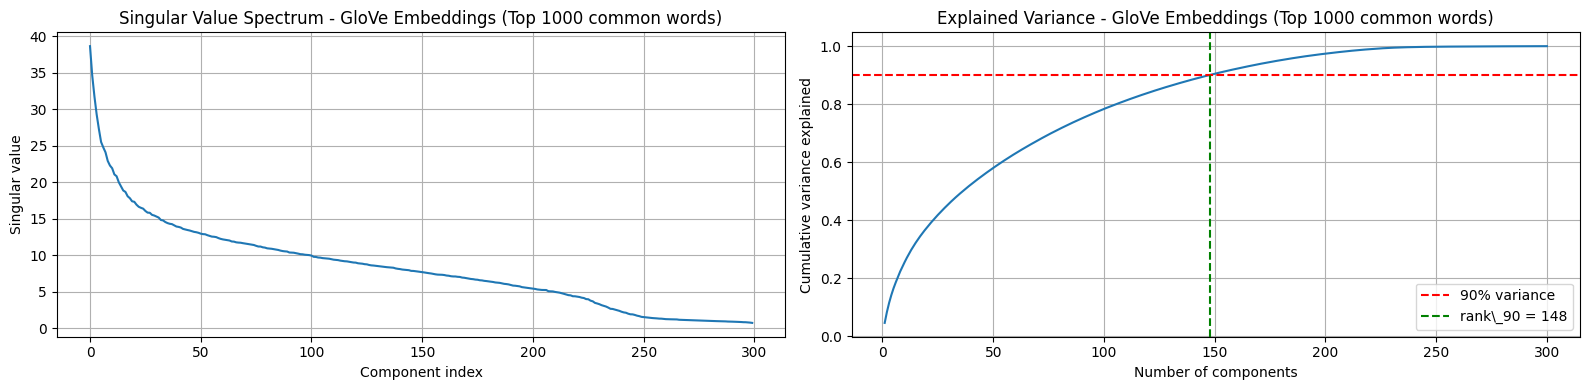

In [173]:
Z_glove_common = torch.tensor(embeddings_glove_common, dtype=torch.float32)
Z_fasttext_common = torch.tensor(embeddings_fasttext_common, dtype=torch.float32)

print(f"RankMe GloVe (common words): {rankMe(Z_glove_common):.2f}")
print(f"RankMe FastText (common words): {rankMe(Z_fasttext_common):.2f}")

U, S, Vt = np.linalg.svd(embeddings_glove_common, full_matrices=False)
explained = np.cumsum(S**2) / np.sum(S**2)
rank_90_common = np.searchsorted(explained, 0.90) + 1
print(f"Rank needed for 90% variance (GloVe common): {rank_90_common}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Scree plot
axes[0].plot(S)
axes[0].set_xlabel('Component index')
axes[0].set_ylabel('Singular value')
axes[0].set_title(f'Singular Value Spectrum - GloVe Embeddings (Top {N} common words)')
axes[0].grid(True)

# Explained variance plot (up to 300 dimensions)
axes[1].plot(np.arange(1, 301), explained[:300])
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90% variance')
axes[1].axvline(x=rank_90_common, color='g', linestyle='--', label=f'rank\_90 = {rank_90_common}')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance explained')
axes[1].set_title(f'Explained Variance - GloVe Embeddings (Top {N} common words)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

<>:85: SyntaxWarning: invalid escape sequence '\_'
<>:85: SyntaxWarning: invalid escape sequence '\_'
/var/folders/5z/3xwg416d0n950g8l42xwjpxr0000gn/T/ipykernel_52101/403706251.py:85: SyntaxWarning: invalid escape sequence '\_'
  ax.axvline(x=rank_90_common, color='gray', linestyle='--', label=f'rank\_90 = {rank_90_common}')


=== Mean Reciprocal Rank ===
MRR:              0.1351  (perfect = 1.0000, random ≈ 0.001000)
Median rank:      50 / 1000
Rank 1 hits:      74 / 1000  (7.40%)
Rank ≤ 10 hits:   268 / 1000  (26.80%)
Iter 1, Anchors 10: MRR=0.1351, MSE=0.0114, Frob=0.1140, Euc=0.3212, Cos=0.5483
=== Mean Reciprocal Rank ===
MRR:              0.2098  (perfect = 1.0000, random ≈ 0.001000)
Median rank:      25 / 1000
Rank 1 hits:      128 / 1000  (12.80%)
Rank ≤ 10 hits:   385 / 1000  (38.50%)
Iter 1, Anchors 20: MRR=0.2098, MSE=0.0119, Frob=0.2389, Euc=0.4693, Cos=0.5543
=== Mean Reciprocal Rank ===
MRR:              0.3405  (perfect = 1.0000, random ≈ 0.001000)
Median rank:      8 / 1000
Rank 1 hits:      249 / 1000  (24.90%)
Rank ≤ 10 hits:   525 / 1000  (52.50%)
Iter 1, Anchors 30: MRR=0.3405, MSE=0.0111, Frob=0.3324, Euc=0.5582, Cos=0.5674
=== Mean Reciprocal Rank ===
MRR:              0.4294  (perfect = 1.0000, random ≈ 0.001000)
Median rank:      4 / 1000
Rank 1 hits:      342 / 1000  (34.20%)
Rank ≤ 

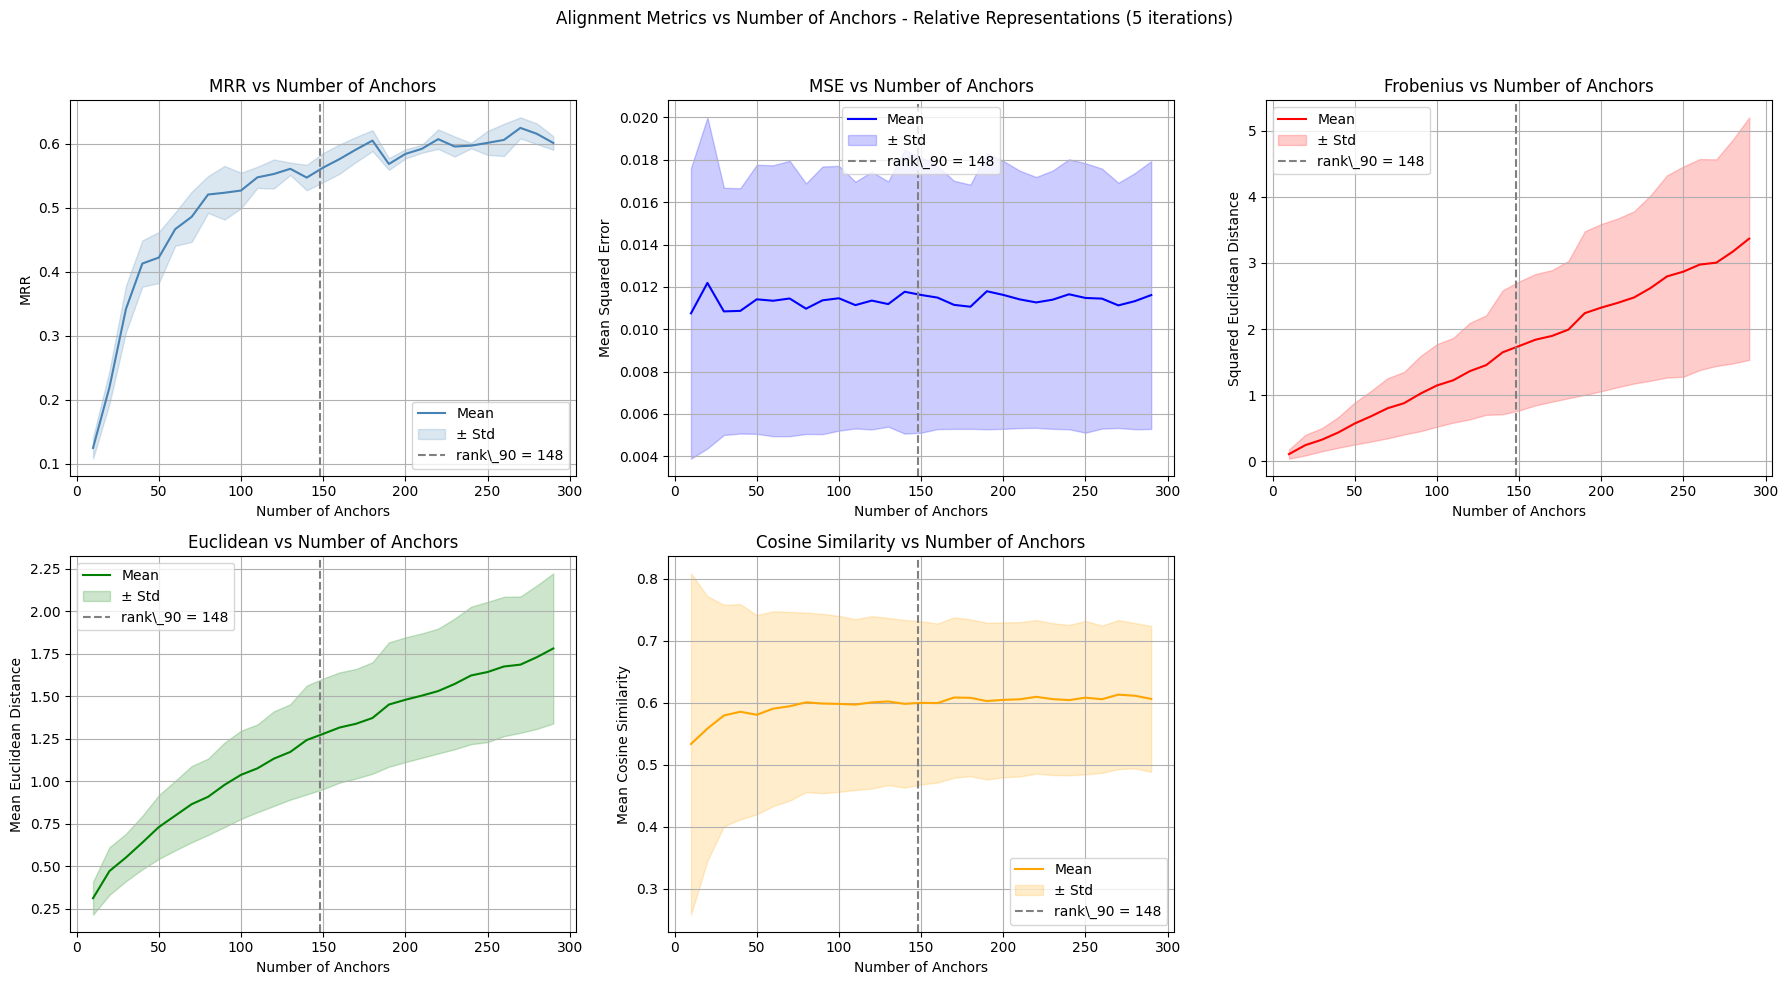

Best MRR:       0.6247 ± 0.0164 at 270 anchors
Best MSE:       0.0108 ± 0.0069 at 10 anchors
Best Frobenius: 0.1075 ± 0.0686 at 10 anchors
Best Euclidean: 0.3126 ± 0.0966 at 10 anchors
Best Cosine:    0.6130 ± 0.1203 at 270 anchors


In [175]:
anchor_counts = list(range(10, 300, 10))
n_iterations = 5

mrr_matrix          = np.zeros((n_iterations, len(anchor_counts)))
mse_mean_matrix     = np.zeros((n_iterations, len(anchor_counts)))
mse_std_matrix      = np.zeros((n_iterations, len(anchor_counts)))
frob_mean_matrix    = np.zeros((n_iterations, len(anchor_counts)))
frob_std_matrix     = np.zeros((n_iterations, len(anchor_counts)))
euc_mean_matrix     = np.zeros((n_iterations, len(anchor_counts)))
euc_std_matrix      = np.zeros((n_iterations, len(anchor_counts)))
cosine_mean_matrix  = np.zeros((n_iterations, len(anchor_counts)))
cosine_std_matrix   = np.zeros((n_iterations, len(anchor_counts)))

for i in range(n_iterations):
    for j, num_anchors in enumerate(anchor_counts):
        np.random.seed(i * 100 + num_anchors)
        anchor_indices = np.random.choice(len(embeddings_glove_common), size=num_anchors, replace=False)

        anchors_glove    = embeddings_glove_common[anchor_indices]
        anchors_fasttext = embeddings_fasttext_common[anchor_indices]

        relrep_glove    = compute_relative_representations(embeddings_glove_common, anchors_glove)
        relrep_fasttext = compute_relative_representations(embeddings_fasttext_common, anchors_fasttext)

        # MRR
        mrr, _ = compute_mrr(relrep_glove, relrep_fasttext)
        mrr_matrix[i, j] = mrr

        # MSE
        mse_per_word = np.mean((relrep_glove - relrep_fasttext) ** 2, axis=1)
        mse_mean_matrix[i, j] = mse_per_word.mean()
        mse_std_matrix[i, j]  = mse_per_word.std()

        # Frobenius
        frob_per_word = np.linalg.norm(relrep_glove - relrep_fasttext, axis=1) ** 2
        frob_mean_matrix[i, j] = frob_per_word.mean()
        frob_std_matrix[i, j]  = frob_per_word.std()

        # Euclidean
        euc_per_word = np.linalg.norm(relrep_glove - relrep_fasttext, axis=1)
        euc_mean_matrix[i, j] = euc_per_word.mean()
        euc_std_matrix[i, j]  = euc_per_word.std()

        # Cosine
        glove_norm = relrep_glove  / (np.linalg.norm(relrep_glove,  axis=1, keepdims=True) + 1e-8)
        ft_norm    = relrep_fasttext / (np.linalg.norm(relrep_fasttext, axis=1, keepdims=True) + 1e-8)
        cos_per_word = np.sum(glove_norm * ft_norm, axis=1)
        cosine_mean_matrix[i, j] = cos_per_word.mean()
        cosine_std_matrix[i, j]  = cos_per_word.std()

        print(f"Iter {i+1}, Anchors {num_anchors}: MRR={mrr:.4f}, "
              f"MSE={mse_mean_matrix[i,j]:.4f}, "
              f"Frob={frob_mean_matrix[i,j]:.4f}, "
              f"Euc={euc_mean_matrix[i,j]:.4f}, "
              f"Cos={cosine_mean_matrix[i,j]:.4f}")

# Average over iterations
avg_mrr         = mrr_matrix.mean(axis=0)
std_mrr         = mrr_matrix.std(axis=0)
avg_mse_mean    = mse_mean_matrix.mean(axis=0)
avg_mse_std     = mse_std_matrix.mean(axis=0)
avg_frob_mean   = frob_mean_matrix.mean(axis=0)
avg_frob_std    = frob_std_matrix.mean(axis=0)
avg_euc_mean    = euc_mean_matrix.mean(axis=0)
avg_euc_std     = euc_std_matrix.mean(axis=0)
avg_cosine_mean = cosine_mean_matrix.mean(axis=0)
avg_cosine_std  = cosine_std_matrix.mean(axis=0)

# Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics = [
    (avg_mrr,         std_mrr,         'steelblue', 'MRR',               'MRR'),
    (avg_mse_mean,    avg_mse_std,     'blue',      'MSE',               'Mean Squared Error'),
    (avg_frob_mean,   avg_frob_std,    'red',       'Frobenius',         'Squared Euclidean Distance'),
    (avg_euc_mean,    avg_euc_std,     'green',     'Euclidean',         'Mean Euclidean Distance'),
    (avg_cosine_mean, avg_cosine_std,  'orange',    'Cosine Similarity', 'Mean Cosine Similarity'),
]

for ax, (mean, std, color, label, ylabel) in zip(axes, metrics):
    ax.plot(anchor_counts, mean, color=color, label='Mean')
    ax.fill_between(anchor_counts, mean - std, mean + std, alpha=0.2, color=color, label='± Std')
    ax.set_xlabel('Number of Anchors')
    ax.axvline(x=rank_90_common, color='gray', linestyle='--', label=f'rank\_90 = {rank_90_common}')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{label} vs Number of Anchors')
    ax.legend()
    ax.grid(True)

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle(f'Alignment Metrics vs Number of Anchors - Relative Representations ({n_iterations} iterations)')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

best_idx = np.argmax(avg_mrr)
print(f"Best MRR:       {avg_mrr[best_idx]:.4f} ± {std_mrr[best_idx]:.4f} at {anchor_counts[best_idx]} anchors")
print(f"Best MSE:       {avg_mse_mean.min():.4f} ± {avg_mse_std[avg_mse_mean.argmin()]:.4f} at {anchor_counts[avg_mse_mean.argmin()]} anchors")
print(f"Best Frobenius: {avg_frob_mean.min():.4f} ± {avg_frob_std[avg_frob_mean.argmin()]:.4f} at {anchor_counts[avg_frob_mean.argmin()]} anchors")
print(f"Best Euclidean: {avg_euc_mean.min():.4f} ± {avg_euc_std[avg_euc_mean.argmin()]:.4f} at {anchor_counts[avg_euc_mean.argmin()]} anchors")
print(f"Best Cosine:    {avg_cosine_mean.max():.4f} ± {avg_cosine_std[avg_cosine_mean.argmax()]:.4f} at {anchor_counts[avg_cosine_mean.argmax()]} anchors")

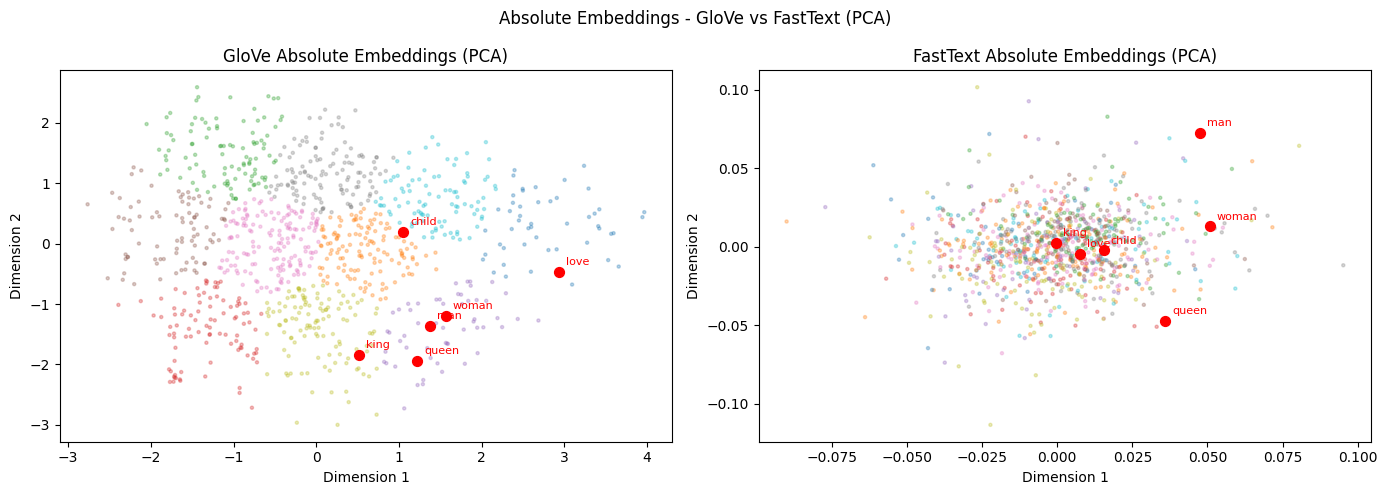

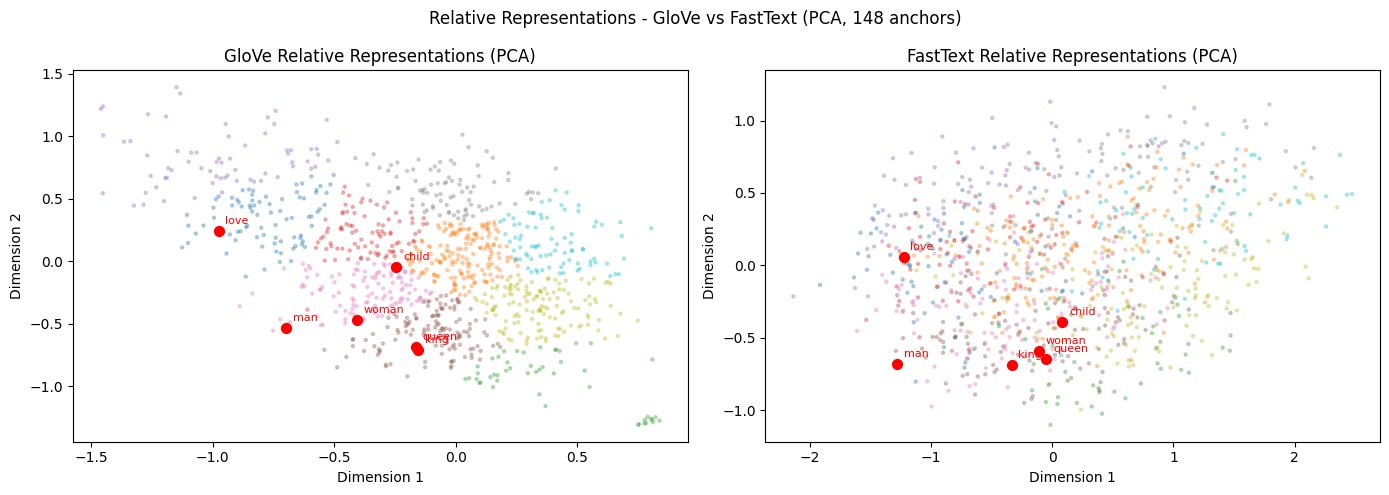

/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


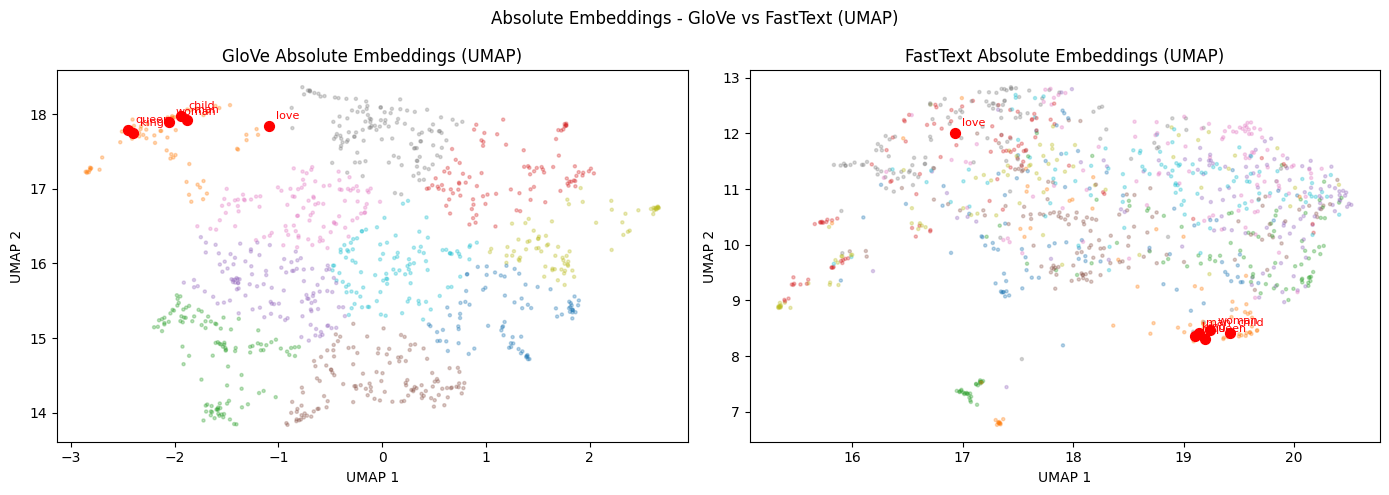

/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KeyboardInterrupt: 

In [ ]:
import umap
from sklearn.cluster import KMeans

# Recompute with the fixed seed before PCA/UMAP
np.random.seed(42)
num_anchors = 148
anchor_indices = np.random.choice(len(embeddings_glove_common), size=num_anchors, replace=False)
anchors_glove    = embeddings_glove_common[anchor_indices]
anchors_fasttext = embeddings_fasttext_common[anchor_indices]
relrep_glove    = compute_relative_representations(embeddings_glove_common, anchors_glove)
relrep_fasttext = compute_relative_representations(embeddings_fasttext_common, anchors_fasttext)

n_clusters = 10

# ── PCA — Absolute ────────────────────────────────────────────────────────────
concat_abs = np.concatenate([embeddings_glove_common, embeddings_fasttext_common], axis=0)
pca_abs = PCA(n_components=2)
pca_transformed_abs = pca_abs.fit_transform(concat_abs)

glove_abs_2d    = pca_transformed_abs[:len(embeddings_glove_common)]
fasttext_abs_2d = pca_transformed_abs[len(embeddings_glove_common):]

kmeans_abs = KMeans(n_clusters=n_clusters, random_state=42).fit(glove_abs_2d)
labels_abs_glove    = kmeans_abs.labels_
labels_abs_fasttext = labels_abs_glove  

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, emb_2d, labels, title in zip(
    axes,
    [glove_abs_2d, fasttext_abs_2d],
    [labels_abs_glove, labels_abs_fasttext],
    ['GloVe Absolute Embeddings (PCA)', 'FastText Absolute Embeddings (PCA)']
):
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, cmap='tab10', alpha=0.3, s=5)
    for word in interesting_words_common:
        if word in words_list_common:
            idx = words_list_common.index(word)
            ax.annotate(word, (emb_2d[idx, 0], emb_2d[idx, 1]),
                       fontsize=8, color='red',
                       xytext=(5, 5), textcoords='offset points')
            ax.scatter(emb_2d[idx, 0], emb_2d[idx, 1], color='red', s=50, zorder=5)
    ax.set_title(title)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
plt.suptitle('Absolute Embeddings - GloVe vs FastText (PCA)')
plt.tight_layout()
plt.show()

# ── PCA — Relative ────────────────────────────────────────────────────────────
concat_relrep = np.concatenate([relrep_glove, relrep_fasttext], axis=0)
pca_relrep = PCA(n_components=2)
pca_transformed_relrep = pca_relrep.fit_transform(concat_relrep)

glove_relrep_2d    = pca_transformed_relrep[:len(relrep_glove)]
fasttext_relrep_2d = pca_transformed_relrep[len(relrep_glove):]

kmeans_relrep_pca = KMeans(n_clusters=n_clusters, random_state=42).fit(glove_relrep_2d)
labels_relrep_pca_glove    = kmeans_relrep_pca.labels_
labels_relrep_pca_fasttext = labels_relrep_pca_glove

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, emb_2d, labels, title in zip(
    axes,
    [glove_relrep_2d, fasttext_relrep_2d],
    [labels_relrep_pca_glove, labels_relrep_pca_fasttext],
    ['GloVe Relative Representations (PCA)', 'FastText Relative Representations (PCA)']
):
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, cmap='tab10', alpha=0.3, s=5)
    for word in interesting_words_common:
        if word in words_list_common:
            idx = words_list_common.index(word)
            ax.annotate(word, (emb_2d[idx, 0], emb_2d[idx, 1]),
                       fontsize=8, color='red',
                       xytext=(5, 5), textcoords='offset points')
            ax.scatter(emb_2d[idx, 0], emb_2d[idx, 1], color='red', s=50, zorder=5)
    ax.set_title(title)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
plt.suptitle(f'Relative Representations - GloVe vs FastText (PCA, {num_anchors} anchors)')
plt.tight_layout()
plt.show()

# ── UMAP — Absolute ───────────────────────────────────────────────────────────
reducer_abs = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42, metric='cosine')
umap_abs = reducer_abs.fit_transform(concat_abs)

glove_abs_umap    = umap_abs[:len(embeddings_glove_common)]
fasttext_abs_umap = umap_abs[len(embeddings_glove_common):]

kmeans_abs_umap = KMeans(n_clusters=n_clusters, random_state=42).fit(glove_abs_umap)
labels_abs_umap_glove    = kmeans_abs_umap.labels_
labels_abs_umap_fasttext = labels_abs_umap_glove

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, emb_2d, labels, title in zip(
    axes,
    [glove_abs_umap, fasttext_abs_umap],
    [labels_abs_umap_glove, labels_abs_umap_fasttext],
    ['GloVe Absolute Embeddings (UMAP)', 'FastText Absolute Embeddings (UMAP)']
):
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, cmap='tab10', alpha=0.3, s=5)
    for word in interesting_words_common:
        if word in words_list_common:
            idx = words_list_common.index(word)
            ax.annotate(word, (emb_2d[idx, 0], emb_2d[idx, 1]),
                       fontsize=8, color='red',
                       xytext=(5, 5), textcoords='offset points')
            ax.scatter(emb_2d[idx, 0], emb_2d[idx, 1], color='red', s=50, zorder=5)
    ax.set_title(title)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
plt.suptitle('Absolute Embeddings - GloVe vs FastText (UMAP)')
plt.tight_layout()
plt.show()

# ── UMAP — Relative ───────────────────────────────────────────────────────────
reducer_relrep = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42, metric='cosine')
umap_relrep = reducer_relrep.fit_transform(concat_relrep)

glove_relrep_umap    = umap_relrep[:len(relrep_glove)]
fasttext_relrep_umap = umap_relrep[len(relrep_glove):]

kmeans_relrep_umap = KMeans(n_clusters=n_clusters, random_state=42).fit(glove_relrep_umap)
labels_relrep_umap_glove    = kmeans_relrep_umap.labels_
labels_relrep_umap_fasttext = labels_relrep_umap_glove

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, emb_2d, labels, title in zip(
    axes,
    [glove_relrep_umap, fasttext_relrep_umap],
    [labels_relrep_umap_glove, labels_relrep_umap_fasttext],
    ['GloVe Relative Representations (UMAP)', 'FastText Relative Representations (UMAP)']
):
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, cmap='tab10', alpha=0.3, s=5)
    for word in interesting_words_common:
        if word in words_list_common:
            idx = words_list_common.index(word)
            ax.annotate(word, (emb_2d[idx, 0], emb_2d[idx, 1]),
                       fontsize=8, color='red',
                       xytext=(5, 5), textcoords='offset points')
            ax.scatter(emb_2d[idx, 0], emb_2d[idx, 1], color='red', s=50, zorder=5)
    ax.set_title(title)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
plt.suptitle(f'Relative Representations - GloVe vs FastText (UMAP, {num_anchors} anchors)')
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate MRR on the absolute vs relative
mrr_absolute, _ = compute_mrr(embeddings_glove_common, embeddings_fasttext_common)
mrr_relative, _ = compute_mrr(relrep_glove, relrep_fasttext)
print(f"MRR Absolute: {mrr_absolute:.4f}")
print(f"MRR Relative: {mrr_relative:.4f}")

=== Mean Reciprocal Rank ===
MRR:              0.0047  (perfect = 1.0000, random ≈ 0.001000)
Median rank:      539 / 1000
Rank 1 hits:      0 / 1000  (0.00%)
Rank ≤ 10 hits:   3 / 1000  (0.30%)
=== Mean Reciprocal Rank ===
MRR:              0.5935  (perfect = 1.0000, random ≈ 0.001000)
Median rank:      1 / 1000
Rank 1 hits:      513 / 1000  (51.30%)
Rank ≤ 10 hits:   740 / 1000  (74.00%)
MRR Absolute: 0.0047
MRR Relative: 0.5935


In [ ]:
# Cosine similarity between the relative representations
glove_relrep_norm = relrep_glove / (np.linalg.norm(relrep_glove, axis=1, keepdims=True) + 1e-8)
ft_relrep_norm    = relrep_fasttext / (np.linalg.norm(relrep_fasttext, axis=1, keepdims=True) + 1e-8)
cosine_sim_relrep = np.sum(glove_relrep_norm * ft_relrep_norm, axis=1)
print(f"Mean Cosine Similarity (Relative): {cosine_sim_relrep.mean():.4f} ± {cosine_sim_relrep.std():.4f}")

Mean Cosine Similarity (Relative): 0.6064 ± 0.1291


In [176]:
# assess the intrinsic dimensionality of the relative representations
U_relrep, S_relrep, Vt_relrep = np.linalg.svd(relrep_glove, full_matrices=False)
explained_relrep = np.cumsum(S_relrep**2) / np.sum(S_relrep**2)
rank_90_relrep = np.searchsorted(explained_relrep, 0.90) + 1
print(f"Rank needed for 90% variance (Relative Representations): {rank_90_relrep}") 

Rank needed for 90% variance (Relative Representations): 44


Anchors: 10, Rank for 90% variance: 7
Anchors: 20, Rank for 90% variance: 13
Anchors: 30, Rank for 90% variance: 16
Anchors: 40, Rank for 90% variance: 19
Anchors: 50, Rank for 90% variance: 22
Anchors: 60, Rank for 90% variance: 24
Anchors: 70, Rank for 90% variance: 29
Anchors: 80, Rank for 90% variance: 30
Anchors: 90, Rank for 90% variance: 32
Anchors: 100, Rank for 90% variance: 31
Anchors: 110, Rank for 90% variance: 33
Anchors: 120, Rank for 90% variance: 33
Anchors: 130, Rank for 90% variance: 36
Anchors: 140, Rank for 90% variance: 38
Anchors: 150, Rank for 90% variance: 38
Anchors: 160, Rank for 90% variance: 37
Anchors: 170, Rank for 90% variance: 38
Anchors: 180, Rank for 90% variance: 39
Anchors: 190, Rank for 90% variance: 41
Anchors: 200, Rank for 90% variance: 41
Anchors: 210, Rank for 90% variance: 43
Anchors: 220, Rank for 90% variance: 41
Anchors: 230, Rank for 90% variance: 41
Anchors: 240, Rank for 90% variance: 40
Anchors: 250, Rank for 90% variance: 42
Anchors: 2

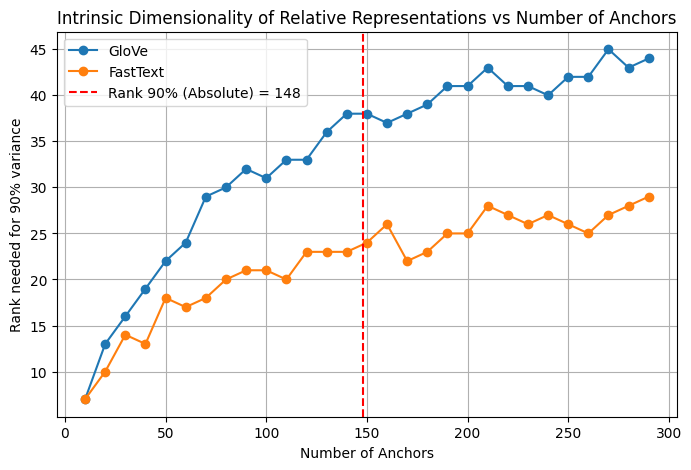

In [183]:
# assess the intrinsic dimensionality of the relative representations at different anchor counts
rank_90_relrep_list_glove = []
rank_90_relrep_list_fasttext = []
anchor_counts = list(range(10, 300, 10))
for num_anchors in anchor_counts:
    np.random.seed(42 + num_anchors)
    anchor_indices = np.random.choice(len(embeddings_glove_common), size=num_anchors, replace=False)
    anchors_glove    = embeddings_glove_common[anchor_indices]
    anchors_fasttext = embeddings_fasttext_common[anchor_indices]
    relrep_glove = compute_relative_representations(embeddings_glove_common, anchors_glove)
    relrep_fasttext = compute_relative_representations(embeddings_fasttext_common, anchors_fasttext)
    U_relrep_glove, S_relrep_glove, Vt_relrep_glove = np.linalg.svd(relrep_glove, full_matrices=False)
    U_relrep_fasttext, S_relrep_fasttext, Vt_relrep_fasttext = np.linalg.svd(relrep_fasttext, full_matrices=False)
    explained_relrep_glove = np.cumsum(S_relrep_glove**2) / np.sum(S_relrep_glove**2)
    explained_relrep_fasttext = np.cumsum(S_relrep_fasttext**2) / np.sum(S_relrep_fasttext**2)
    rank_90_glove = np.searchsorted(explained_relrep_glove, 0.90) + 1
    rank_90_fasttext = np.searchsorted(explained_relrep_fasttext, 0.90) + 1
    rank_90_relrep_list_glove.append(rank_90_glove)
    rank_90_relrep_list_fasttext.append(rank_90_fasttext)
    print(f"Anchors: {num_anchors}, Rank for 90% variance: {rank_90_glove}")
plt.figure(figsize=(8, 5))
plt.plot(anchor_counts, rank_90_relrep_list_glove, marker='o', label='GloVe')
plt.plot(anchor_counts, rank_90_relrep_list_fasttext, marker='o', label='FastText')
plt.axvline(x=rank_90_common, color='r', linestyle='--', label=f'Rank 90% (Absolute) = {rank_90_common}')
plt.xlabel('Number of Anchors')
plt.ylabel('Rank needed for 90% variance')
plt.title('Intrinsic Dimensionality of Relative Representations vs Number of Anchors')
plt.legend()
plt.grid(True)
plt.show()